---
## 1. Imports

In [1]:
import pickle
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, average_precision_score,
    classification_report
)

print(f"PyTorch: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

PyTorch: 2.11.0+cpu
Device : cpu


---
## 2. Load Data

In [2]:
with open(r'D:\Uni\Year_3_sem_2\XAI\Project\phase_2\transformer_processed_data\transformer_train_data.pkl', 'rb') as f:
    raw = pickle.load(f)

X        = raw['X'].astype(np.float32)
y        = raw['y'].astype(np.int64)
FEATURES = list(raw['features'])

N_SAMPLES, SEQ_LEN, N_FEATURES = X.shape

# (samples, time_steps, features)
print(f"X        : {X.shape} ")
print(f"y        : {y.shape}")
print(f"Features : {N_FEATURES}  ->  {FEATURES}")

X        : (49346, 6, 45) 
y        : (49346,)
Features : 45  ->  ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'HR_Delta', 'SBP_Delta', 'Temp_Delta', 'Resp_Delta', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'ICULOS', 'high_oxygen_support', 'baseline_risk_index', 'NEWS', 'SOFA']


---
## 3. Train / Validation Split & DataLoaders

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")

BATCH_SIZE = 256

def make_loader(X_np, y_np, shuffle):
    ds = TensorDataset(
        torch.tensor(X_np, dtype=torch.float32),
        torch.tensor(y_np, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)

Train : (39476, 6, 45)
Val   : (9870, 6, 45)


---
## 4. Transformer Architecture


In [ ]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding for temporal sequences."""

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 64):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class SepsisTransformer(nn.Module):

    def __init__(
        self,
        n_features:      int   = 45,
        seq_len:         int   = 6,
        d_model:         int   = 128,   # embedding dim; must be divisible by n_heads
        n_heads:         int   = 8,     # paper: 8 attention heads
        num_layers:      int   = 4,     # paper: 4 encoder layers
        dim_feedforward: int   = 512,   # paper: FF dim = 512
        dropout:         float = 0.5,   # paper: dropout = 0.3
    ):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout, max_len=seq_len + 4)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            activation      = 'relu',
            batch_first     = True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)   # (B, T, d_model)
        x = self.pos_enc(x)      # (B, T, d_model)
        x = self.encoder(x)      # (B, T, d_model)
        x = x.mean(dim=1)        # (B, d_model)  global average pool
        x = self.classifier(x)   # (B, 1)
        return x.squeeze(-1)     # (B,)


model = SepsisTransformer(
    n_features      = N_FEATURES,
    seq_len         = SEQ_LEN,
    d_model         = 128,
    n_heads         = 8,
    num_layers      = 4,
    dim_feedforward = 512,
    dropout         = 0.5,
).to(device)

print(f"\nTrainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Trainable params: 807,553


---
## 5. Loss, Optimizer & Class-Imbalance Handling


In [5]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()

# pos_weight = 1.0 because SMOTE already balanced the classes
criterion = nn.BCEWithLogitsLoss()

# Adam lr=0.001 — exact paper spec
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3 , weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

---
## 6. Training Loop

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_probs, all_labels = [], []

    with (torch.enable_grad() if training else torch.no_grad()):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * len(yb)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(yb.cpu().numpy().astype(int).tolist())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss   = total_loss / len(all_labels)
    accuracy   = accuracy_score(all_labels, (all_probs >= 0.5).astype(int))
    auroc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, accuracy, auroc

In [7]:
NUM_EPOCHS     = 50
EARLY_STOP_PAT = 10

history = {k: [] for k in
           ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_auroc', 'val_auroc']}

best_val_auroc   = -1.0
patience_counter = 0

header = (f"{'Epochs':>4} | {'Training Loss':>8} | {'Validation Loss':>8} | "
          f"{'Training Acc':>7} | {'Validation Acc':>7} | {'Training AUROC':>8} | {'Validation AUROC':>8}")
print(header)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_auc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_auc = run_epoch(model, val_loader,   criterion, None)

    scheduler.step(vl_auc)

    for key, val in zip(history.keys(),
                        [tr_loss, vl_loss, tr_acc, vl_acc, tr_auc, vl_auc]):
        history[key].append(val)

    print(f"{epoch:>4} | {tr_loss:>8.4f} | {vl_loss:>8.4f} | "
          f"{tr_acc:>7.4f} | {vl_acc:>7.4f} | {tr_auc:>8.4f} | {vl_auc:>8.4f}")

    if vl_auc > best_val_auroc:
        best_val_auroc   = vl_auc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_transformer.pt')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PAT:
            print(f"\nEarly stop at epoch {epoch}.")
            break

print(f"\nBest Val AUROC: {best_val_auroc:.4f}")

Epochs | Training Loss | Validation Loss | Training Acc | Validation Acc | Training AUROC | Validation AUROC
   1 |   0.6062 |   0.5309 |  0.6688 |  0.7209 |   0.7218 |   0.8401
   2 |   0.4363 |   0.4106 |  0.8029 |  0.8127 |   0.8763 |   0.9456
   3 |   0.3293 |   0.3161 |  0.8618 |  0.8739 |   0.9285 |   0.9621
   4 |   0.2676 |   0.2627 |  0.8917 |  0.9150 |   0.9523 |   0.9601
   5 |   0.2262 |   0.2708 |  0.9128 |  0.9172 |   0.9651 |   0.9799
   6 |   0.1986 |   0.2555 |  0.9258 |  0.9099 |   0.9726 |   0.9844
   7 |   0.1823 |   0.1829 |  0.9324 |  0.9355 |   0.9767 |   0.9908
   8 |   0.1636 |   0.1790 |  0.9414 |  0.9318 |   0.9807 |   0.9905
   9 |   0.1498 |   0.1218 |  0.9460 |  0.9588 |   0.9838 |   0.9943
  10 |   0.1379 |   0.1487 |  0.9501 |  0.9445 |   0.9860 |   0.9947
  11 |   0.1275 |   0.1647 |  0.9547 |  0.9498 |   0.9880 |   0.9932
  12 |   0.1233 |   0.1324 |  0.9553 |  0.9600 |   0.9889 |   0.9952
  13 |   0.1133 |   0.1539 |  0.9609 |  0.9528 |   0.9903 |   0

---
## 7. Training Curves — Detect Overfitting

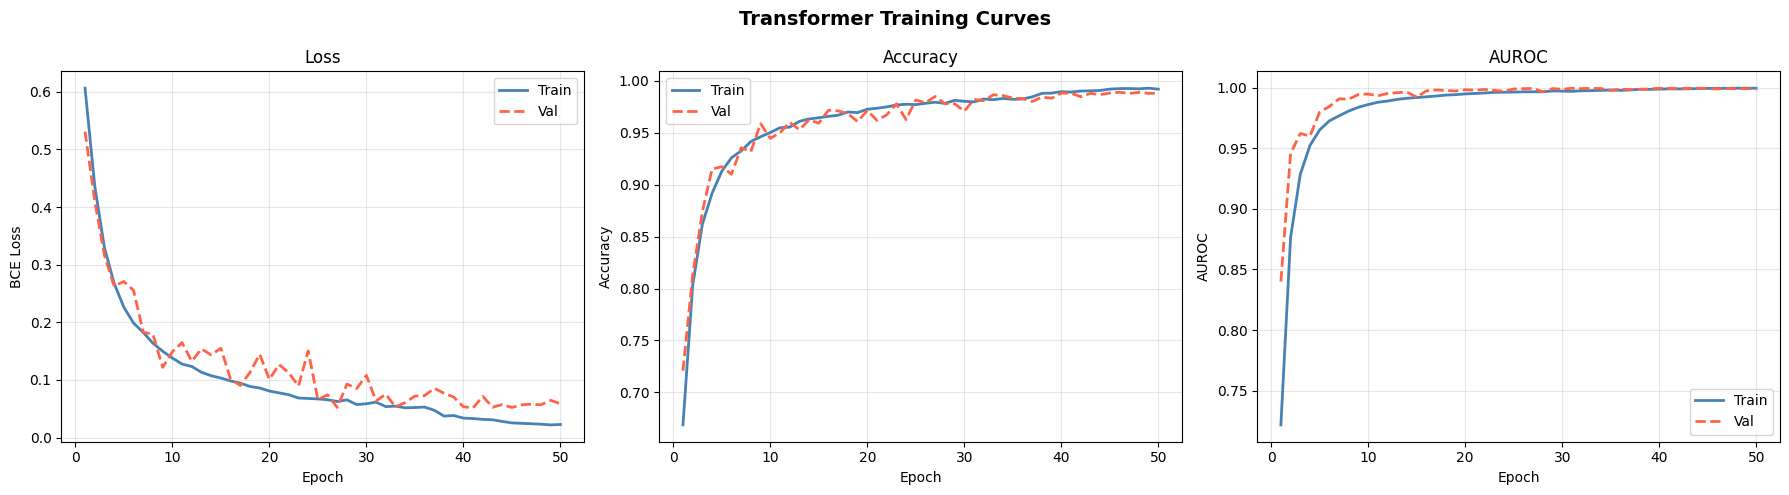

Overfitting gap (last epoch AUROC): 0.0006
OK: Model generalises well.


In [8]:
eps = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Transformer Training Curves', fontsize=14, fontweight='bold')

pairs = [
    ('train_loss',  'val_loss',  'Loss',     'BCE Loss'),
    ('train_acc',   'val_acc',   'Accuracy', 'Accuracy'),
    ('train_auroc', 'val_auroc', 'AUROC',    'AUROC'),
]
for ax, (tr_key, vl_key, title, ylabel) in zip(axes, pairs):
    ax.plot(eps, history[tr_key], label='Train', color='steelblue', lw=2)
    ax.plot(eps, history[vl_key], label='Val',   color='tomato',    lw=2, linestyle='--')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

gap = history['train_auroc'][-1] - history['val_auroc'][-1]
print(f"Overfitting gap (last epoch AUROC): {gap:.4f}")
print("WARNING: Overfitting detected." if gap > 0.05 else "OK: Model generalises well.")

---
## 8. Final Evaluation (Best Checkpoint)

In [10]:
model.load_state_dict(torch.load('best_transformer.pt', map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        probs = torch.sigmoid(model(xb.to(device))).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(yb.numpy().astype(int).tolist())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= 0.5).astype(int)

auroc = roc_auc_score(all_labels, all_probs)
auprc = average_precision_score(all_labels, all_probs)
acc   = accuracy_score(all_labels, all_preds)

print("=" * 42)
print("  Validation Results  (Best Checkpoint)")
print("=" * 42)
print(f"  AUROC    : {auroc:.4f}")
print(f"  AUPRC    : {auprc:.4f}")
print(f"  Accuracy : {acc:.4f}")
print("=" * 42)
print()
print(classification_report(all_labels, all_preds, target_names=['No Sepsis', 'Sepsis']))

  Validation Results  (Best Checkpoint)
  AUROC    : 0.9995
  AUPRC    : 0.9994
  Accuracy : 0.9865

              precision    recall  f1-score   support

   No Sepsis       1.00      0.97      0.99      4935
      Sepsis       0.97      1.00      0.99      4935

    accuracy                           0.99      9870
   macro avg       0.99      0.99      0.99      9870
weighted avg       0.99      0.99      0.99      9870



---
# Interpretability

---
## Technique 1 — SHAP (DeepExplainer)


In [11]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


C:\Users\nour1\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# Wrapper so SHAP gets a single (B,1) output
class ModelWrapper(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m(x).unsqueeze(-1)

wrapped = ModelWrapper(model).to(device)
wrapped.eval()

# GradientExplainer works correctly with Transformer architectures
bg_t   = torch.tensor(X_train[:100], dtype=torch.float32).to(device)
test_t = torch.tensor(X_val[:200],dtype=torch.float32).to(device)

explainer   = shap.GradientExplainer(wrapped, bg_t)
shap_values = explainer.shap_values(test_t)   # (200, 6, 45, 1)

sv = np.array(shap_values[0] if isinstance(shap_values, list) else shap_values)
if sv.ndim == 4:
    sv = sv.squeeze(-1)   # (200, 6, 45)

shap_importance = np.abs(sv).mean(axis=(0, 1))   # (45,) global per-feature
sorted_idx      = np.argsort(shap_importance)[::-1]

print("Top 10 features by mean |SHAP|:")
for r, i in enumerate(sorted_idx[:10], 1):
    print(f"  {r:>2}. {FEATURES[i]:<22}  {shap_importance[i]:.5f}")

Top 10 features by mean |SHAP|:
   1. Temp                    0.20891
   2. HR_Delta                0.17934
   3. NEWS                    0.17672
   4. Resp_Delta              0.16069
   5. DBP                     0.15568
   6. BUN                     0.15528
   7. Gender                  0.14567
   8. Potassium               0.13477
   9. O2Sat                   0.13392
  10. Age                     0.12510


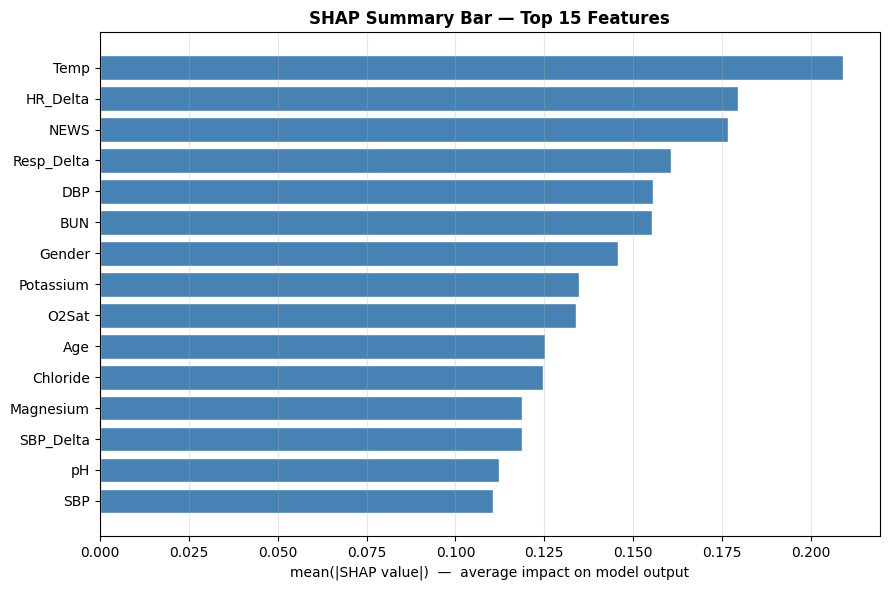

In [13]:
# ── (1) Summary Bar — mirrors Figure 3 of the paper ──
TOP_N    = 15
top_idx  = sorted_idx[:TOP_N][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(TOP_N), shap_importance[top_idx], color='steelblue', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([FEATURES[i] for i in top_idx], fontsize=10)
ax.set_xlabel('mean(|SHAP value|)  —  average impact on model output', fontsize=10)
ax.set_title(f'SHAP Summary Bar — Top {TOP_N} Features', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_bar_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

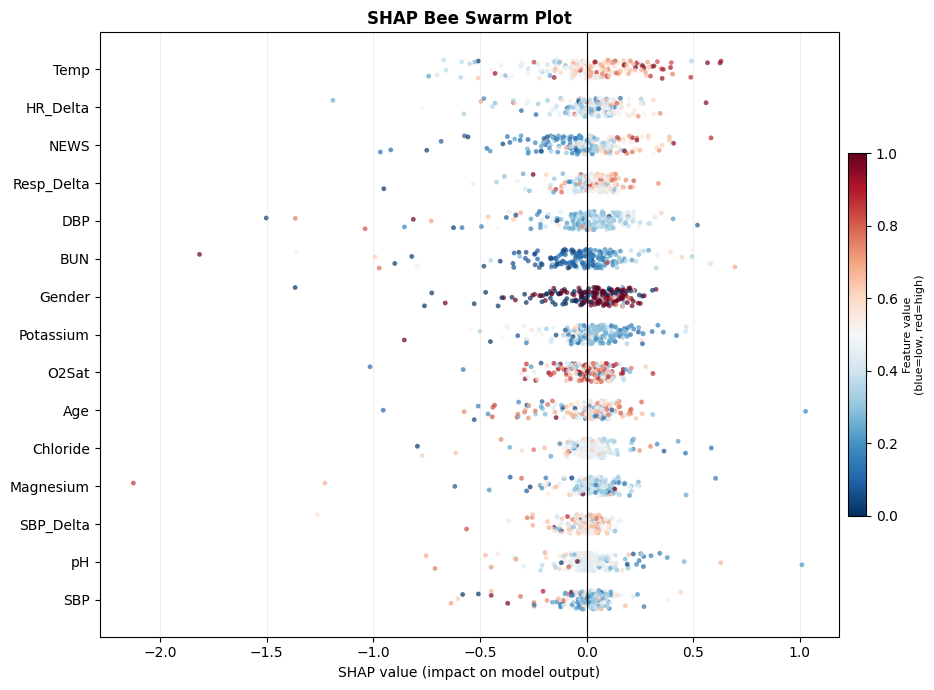

In [14]:
# ── (2) Bee Swarm — mirrors Figure 4 of the paper ──
sv_flat   = sv.mean(axis=1)          # (200, 45)  avg over time steps
X_flat_bg = X_val[:200].mean(axis=1) # (200, 45)  avg feature value over time

fig, ax = plt.subplots(figsize=(10, 7))
for row, feat_i in enumerate(sorted_idx[:TOP_N][::-1]):
    sv_col   = sv_flat[:, feat_i]
    feat_col = X_flat_bg[:, feat_i]
    jitter   = np.random.uniform(-0.25, 0.25, len(sv_col))
    norm     = plt.Normalize(feat_col.min(), feat_col.max())
    colors   = plt.cm.RdBu_r(norm(feat_col))
    ax.scatter(sv_col, row + jitter, c=colors, s=12, alpha=0.7, linewidths=0)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([FEATURES[i] for i in sorted_idx[:TOP_N][::-1]], fontsize=10)
ax.set_xlabel('SHAP value (impact on model output)', fontsize=10)
ax.set_title('SHAP Bee Swarm Plot', fontsize=12, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdBu_r'); sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.01, shrink=0.6)
cb.set_label('Feature value\n(blue=low, red=high)', fontsize=8)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('shap_beeswarm_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

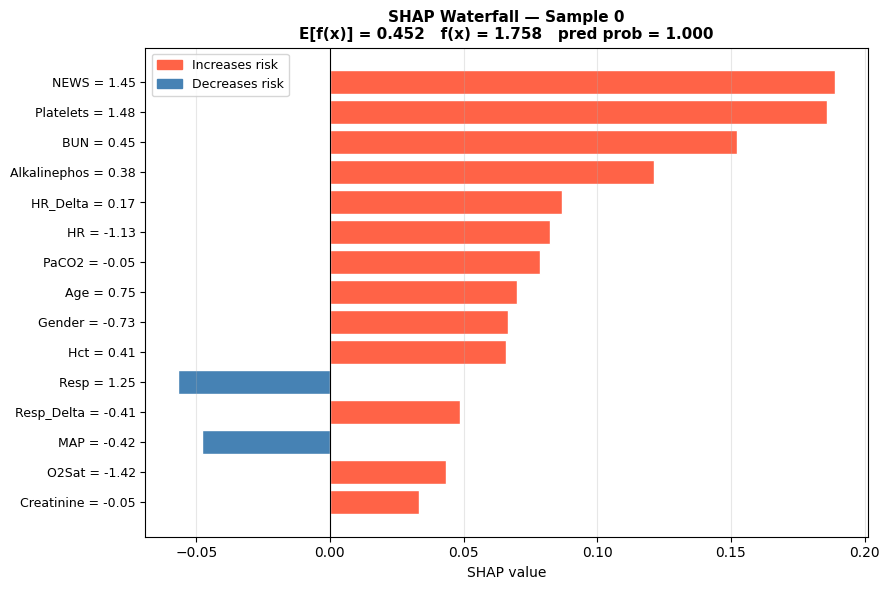

In [15]:
# ── (3) Waterfall — mirrors Figure 5 of the paper ──
val_probs_200 = torch.sigmoid(
    model(torch.tensor(X_val[:200], dtype=torch.float32).to(device))
).detach().cpu().numpy()

pos_idx_200 = np.where(y_val[:200] == 1)[0]
sample_i    = int(pos_idx_200[0]) if len(pos_idx_200) > 0 else int(np.argmax(val_probs_200))

sv_sample  = sv_flat[sample_i]
with torch.no_grad():
    base_value = float(torch.sigmoid(wrapped(bg_t)).mean().cpu())
fx         = base_value + sv_sample.sum()

order  = np.argsort(np.abs(sv_sample))[::-1][:15]
names  = [f"{FEATURES[i]} = {X_flat_bg[sample_i, i]:.2f}" for i in order]
vals   = sv_sample[order]

fig, ax = plt.subplots(figsize=(9, 6))
colors  = ['tomato' if v > 0 else 'steelblue' for v in vals[::-1]]
ax.barh(range(15), vals[::-1], color=colors, edgecolor='white')
ax.set_yticks(range(15))
ax.set_yticklabels(names[::-1], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('SHAP value', fontsize=10)
ax.set_title(
    f'SHAP Waterfall — Sample {sample_i}\n'
    f'E[f(x)] = {base_value:.3f}   f(x) = {fx:.3f}   '
    f'pred prob = {val_probs_200[sample_i]:.3f}',
    fontsize=11, fontweight='bold'
)
ax.legend(handles=[
    mpatches.Patch(color='tomato',    label='Increases risk'),
    mpatches.Patch(color='steelblue', label='Decreases risk')
], fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_waterfall_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Technique 2 — Attention Weight Visualization


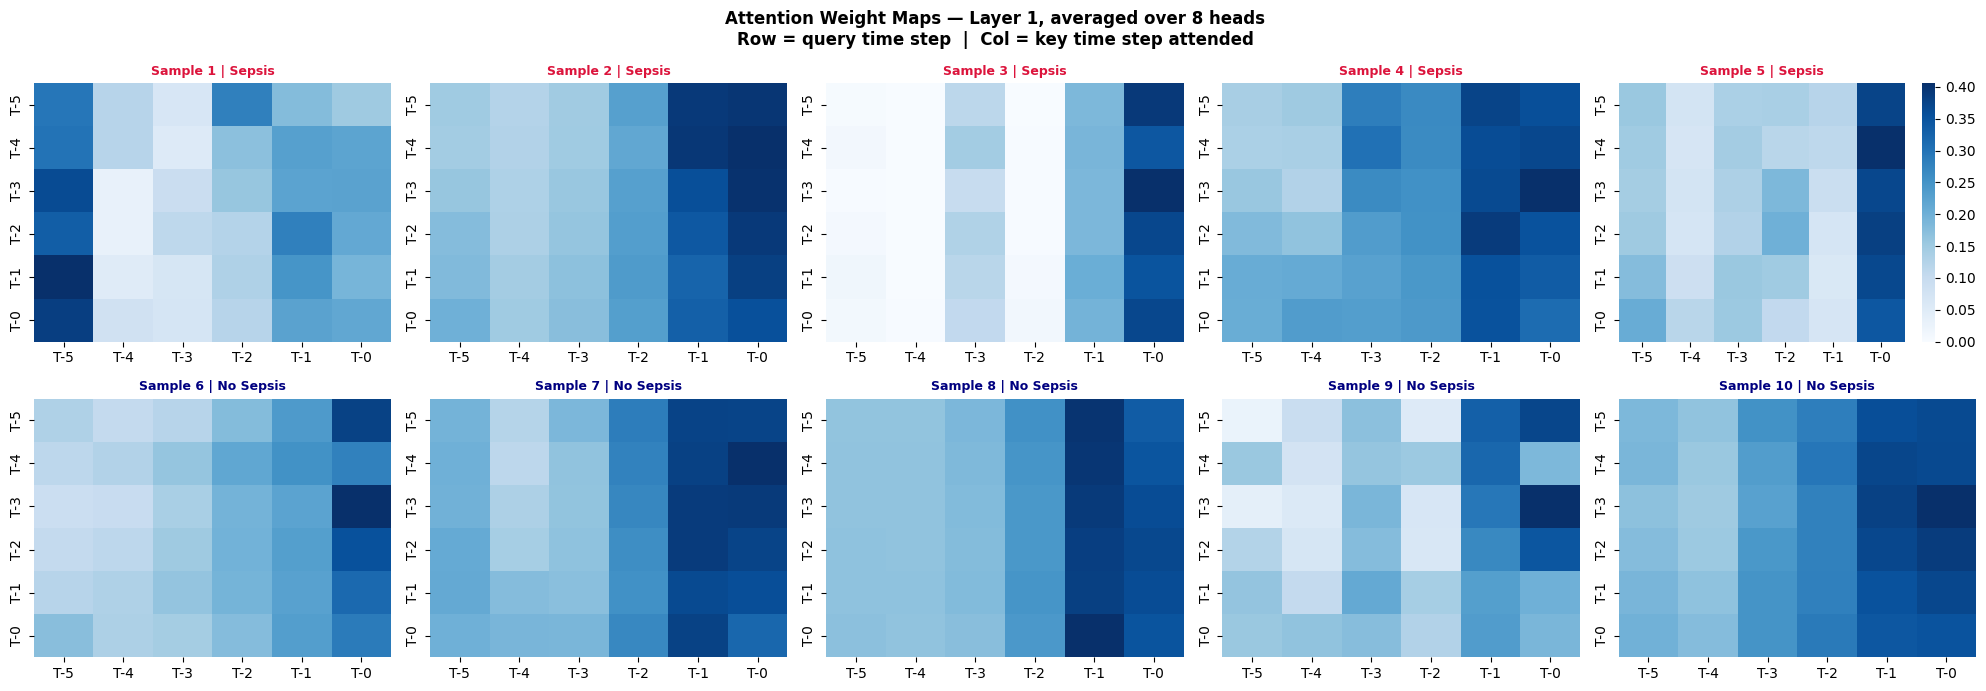

In [16]:
def get_attention_weights(model, x_tensor):
    """
    Extracts attention weights from the first encoder layer.
    Returns shape: (batch, n_heads, seq_len, seq_len)
    """
    model.eval()
    with torch.no_grad():
        x = model.input_proj(x_tensor)
        x = model.pos_enc(x)
        first_layer = model.encoder.layers[0]
        _, attn_weights = first_layer.self_attn(
            x, x, x, need_weights=True, average_attn_weights=False
        )
    return attn_weights.cpu().numpy()   # (B, n_heads, T, T)


pos_samples = X_val[y_val == 1][:5]
neg_samples = X_val[y_val == 0][:5]
combo       = np.concatenate([pos_samples, neg_samples], axis=0)
labels_c    = ['Sepsis'] * 5 + ['No Sepsis'] * 5

x_t  = torch.tensor(combo, dtype=torch.float32).to(device)
attn = get_attention_weights(model, x_t)    # (10, 8, 6, 6)
attn_mean = attn.mean(axis=1)               # (10, 6, 6)  avg over heads

time_labels = [f"T-{5-i}" if i < 5 else "T-0" for i in range(SEQ_LEN)]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle(
    'Attention Weight Maps — Layer 1, averaged over 8 heads\n'
    'Row = query time step  |  Col = key time step attended',
    fontsize=12, fontweight='bold'
)
for i, ax in enumerate(axes.flat):
    sns.heatmap(
        attn_mean[i], ax=ax, cmap='Blues',
        xticklabels=time_labels, yticklabels=time_labels,
        vmin=0, cbar=(i == 4)
    )
    color = 'crimson' if labels_c[i] == 'Sepsis' else 'navy'
    ax.set_title(f"Sample {i+1} | {labels_c[i]}", fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('attention_maps_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

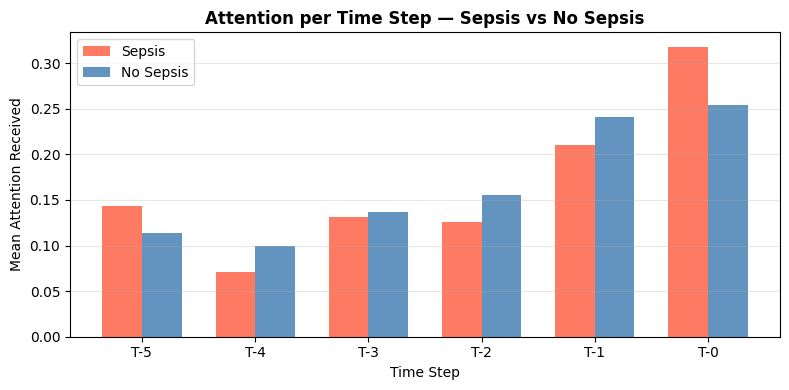

In [17]:
# ── Which time step receives the most attention, by class ──
attn_received = attn_mean.mean(axis=1)   # (10, 6) — mean attention each T receives
pos_attn = attn_received[:5].mean(axis=0)
neg_attn = attn_received[5:].mean(axis=0)

x_pos = np.arange(SEQ_LEN)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos - width/2, pos_attn, width, label='Sepsis',    color='tomato',    alpha=0.85)
ax.bar(x_pos + width/2, neg_attn, width, label='No Sepsis', color='steelblue', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(time_labels)
ax.set_xlabel('Time Step')
ax.set_ylabel('Mean Attention Received')
ax.set_title('Attention per Time Step — Sepsis vs No Sepsis', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_timesteps_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Technique 3 — Integrated Gradients



In [18]:
def integrated_gradients(model, x, baseline=None, steps=50):
    """
    Integrated Gradients attribution for a single sample.

    Parameters
    ----------
    x        : np.ndarray (1, seq_len, n_features)
    baseline : np.ndarray same shape (default: zeros)
    steps    : number of interpolation steps

    Returns
    -------
    attributions : np.ndarray (seq_len, n_features)
    """
    model.eval()
    if baseline is None:
        baseline = np.zeros_like(x)

    x_t        = torch.tensor(x,        dtype=torch.float32).to(device)
    baseline_t = torch.tensor(baseline, dtype=torch.float32).to(device)

    alphas = torch.linspace(0, 1, steps).to(device)             # (steps,)
    interp = (baseline_t + alphas[:, None, None, None]
              * (x_t - baseline_t)).squeeze(1)                   # (steps, T, F)
    interp.requires_grad_(True)

    logits = model(interp)   # (steps,)
    logits.sum().backward()

    avg_grads = interp.grad.detach().cpu().numpy().mean(axis=0)  # (T, F)
    attrs     = (x[0] - baseline[0]) * avg_grads                 # (T, F)
    return attrs


pos_samp5 = X_val[y_val == 1][:5]
ig_attrs  = [integrated_gradients(model, pos_samp5[i:i+1]) for i in range(5)]
print(f"IG shape per sample: {ig_attrs[0].shape}  (time_steps, features)")

IG shape per sample: (6, 45)  (time_steps, features)


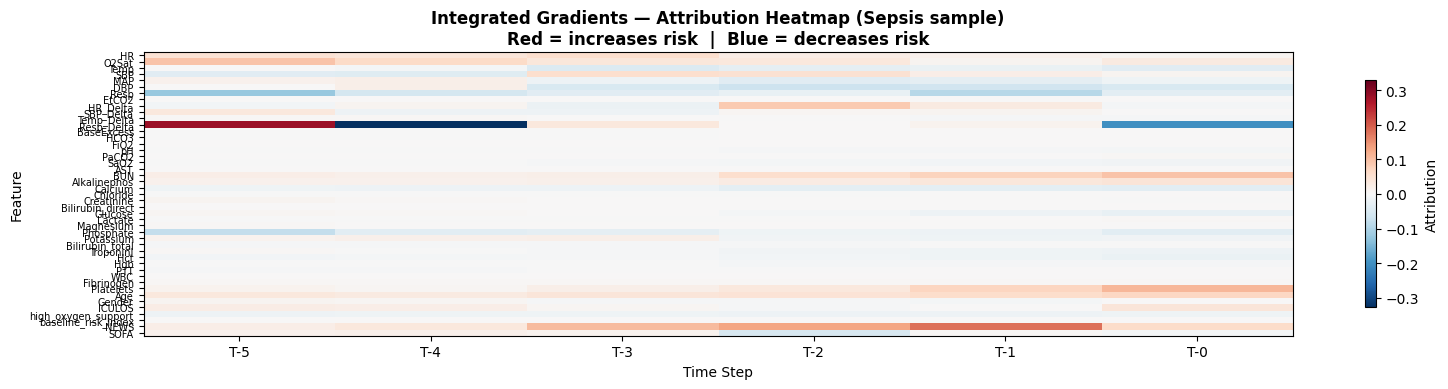

In [19]:
# ── Heatmap for first positive sample ──
attr_map = ig_attrs[0]   # (6, 45)
vmax     = np.abs(attr_map).max()

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(attr_map.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURES, fontsize=7)
ax.set_xticks(range(SEQ_LEN))
ax.set_xticklabels([f"T-{5-i}" if i < 5 else "T-0" for i in range(SEQ_LEN)])
ax.set_xlabel('Time Step')
ax.set_ylabel('Feature')
ax.set_title(
    'Integrated Gradients — Attribution Heatmap (Sepsis sample)\n'
    'Red = increases risk  |  Blue = decreases risk',
    fontweight='bold'
)
plt.colorbar(im, ax=ax, shrink=0.8, label='Attribution')
plt.tight_layout()
plt.savefig('ig_heatmap_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

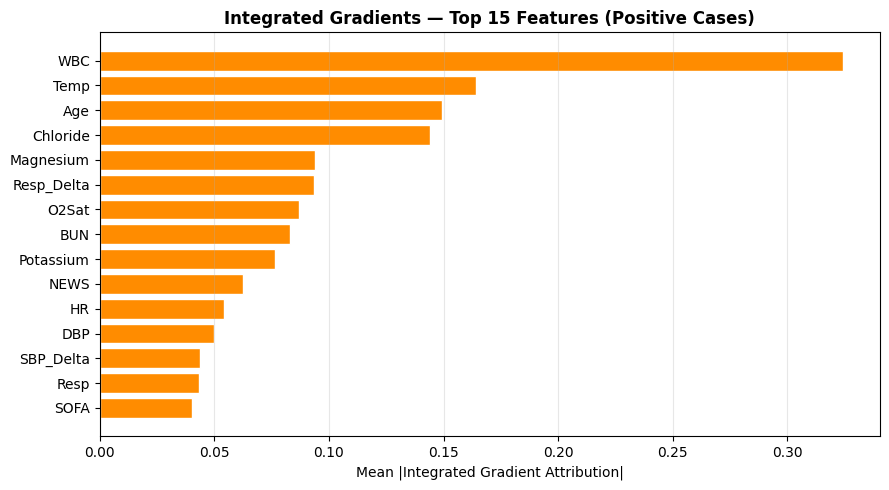

In [20]:
# ── Global IG bar: mean |attribution| over samples and time steps ──
ig_stack  = np.stack(ig_attrs, axis=0)         # (5, 6, 45)
ig_global = np.abs(ig_stack).mean(axis=(0,1))  # (45,)
ig_sorted = np.argsort(ig_global)[::-1]

TOP_N = 15
fig, ax = plt.subplots(figsize=(9, 5))
idx_plot = ig_sorted[:TOP_N][::-1]
ax.barh(range(TOP_N), ig_global[idx_plot], color='darkorange', edgecolor='white')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels([FEATURES[i] for i in idx_plot], fontsize=10)
ax.set_xlabel('Mean |Integrated Gradient Attribution|', fontsize=10)
ax.set_title(f'Integrated Gradients — Top {TOP_N} Features (Positive Cases)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ig_bar_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Technique 4 — LIME (Local Interpretable Model-Agnostic Explanations)


In [21]:
try:
    from lime import lime_tabular
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime', '-q'])
    from lime import lime_tabular

# Flatten (N, 6, 45) -> (N, 270) with named features: "HR_T-5", ..., "SOFA_T-0"
time_step_labels   = [f"T-{5-t}" if t < 5 else "T-0" for t in range(SEQ_LEN)]
flat_feature_names = [
    f"{feat}_{t_lbl}"
    for t_lbl in time_step_labels
    for feat in FEATURES
]

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)

def predict_fn_lime(x_flat):
    x_3d  = x_flat.reshape(-1, SEQ_LEN, N_FEATURES)
    x_t   = torch.tensor(x_3d, dtype=torch.float32).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x_t)).cpu().numpy()
    return np.column_stack([1 - probs, probs])

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data         = X_train_flat,
    feature_names         = flat_feature_names,
    class_names           = ['No Sepsis', 'Sepsis'],
    discretize_continuous = True,
    mode                  = 'classification',
    random_state          = SEED
)
print(f"LIME explainer ready.  Flat feature space: {len(flat_feature_names)}")

LIME explainer ready.  Flat feature space: 270


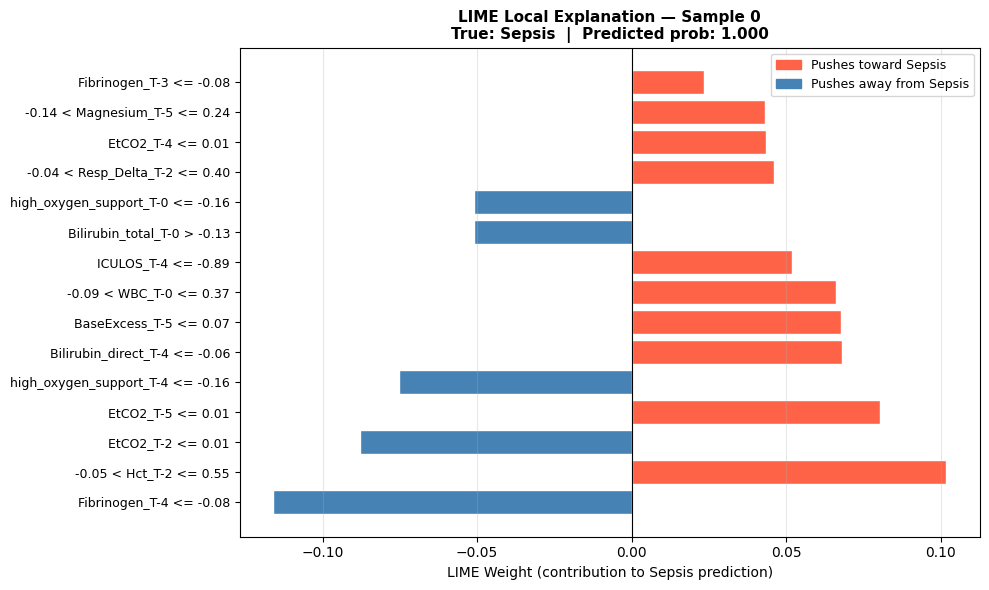

In [22]:
# ── Local explanation for one positive sample ──
pos_idx_val = np.where(y_val == 1)[0]
sample_idx  = int(pos_idx_val[0]) if len(pos_idx_val) > 0 else 0
sample_flat = X_val_flat[sample_idx]
true_label  = y_val[sample_idx]

lime_exp = lime_explainer.explain_instance(
    sample_flat, predict_fn_lime,
    num_features=15, num_samples=500, labels=(1,)
)
lime_feat, lime_wt = zip(*lime_exp.as_list(label=1))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if w > 0 else 'steelblue' for w in lime_wt]
ax.barh(range(len(lime_feat)), list(lime_wt), color=colors, edgecolor='white')
ax.set_yticks(range(len(lime_feat)))
ax.set_yticklabels(list(lime_feat), fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('LIME Weight (contribution to Sepsis prediction)', fontsize=10)
pred_prob = predict_fn_lime(sample_flat.reshape(1, -1))[0, 1]
ax.set_title(
    f'LIME Local Explanation — Sample {sample_idx}\n'
    f'True: {"Sepsis" if true_label else "No Sepsis"}  |  Predicted prob: {pred_prob:.3f}',
    fontsize=11, fontweight='bold'
)
ax.legend(handles=[
    mpatches.Patch(color='tomato',    label='Pushes toward Sepsis'),
    mpatches.Patch(color='steelblue', label='Pushes away from Sepsis')
], fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lime_local_trial2.png', dpi=150, bbox_inches='tight')
plt.show()

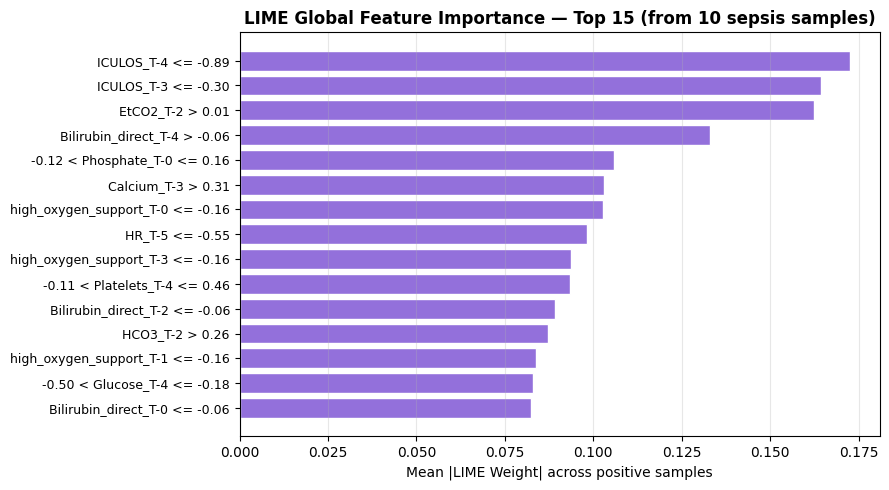

In [23]:
# ── Aggregate LIME over multiple positive samples -> global importance ──
N_LIME   = min(10, len(pos_idx_val))
lime_agg = {}

for idx in pos_idx_val[:N_LIME]:
    exp = lime_explainer.explain_instance(
        X_val_flat[idx], predict_fn_lime,
        num_features=15, num_samples=300, labels=(1,)
    )
    for feat, weight in exp.as_list(label=1):
        lime_agg[feat] = lime_agg.get(feat, []) + [abs(weight)]

lime_global = sorted(
    {k: np.mean(v) for k, v in lime_agg.items()}.items(),
    key=lambda x: x[1], reverse=True
)[:15]
feat_names, feat_vals = zip(*lime_global)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(feat_names))[::-1], list(feat_vals),
        color='mediumpurple', edgecolor='white')
ax.set_yticks(range(len(feat_names)))
ax.set_yticklabels(list(feat_names)[::-1], fontsize=9)
ax.set_xlabel('Mean |LIME Weight| across positive samples', fontsize=10)
ax.set_title(f'LIME Global Feature Importance — Top 15 (from {N_LIME} sepsis samples)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lime_global_trial2.png', dpi=150, bbox_inches='tight')
plt.show()